<a href="https://colab.research.google.com/github/Aleeza-GH/ML-learning-journey/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/loan_approval.csv')
print(df.head())

   Age  Income  CreditScore  LoanAmount  EmploymentYears  ExistingLoans  \
0   50   27717          759      387108                3              0   
1   36   84676          600      218509               16              1   
2   29   52952          602      258944                8              3   
3   42  111444          586      169006               23              1   
4   40   67460          694      286440                1              2   

   Education MaritalStatus PropertyOwned  Approved  
0  Bachelors       Married            No         1  
1      Inter        Single            No         1  
2      Inter       Married            No         0  
3  Bachelors      Divorced            No         1  
4      Inter        Single           Yes         1  


In [ ]:
print(df.shape)

(1000, 10)


In [ ]:
print(df.info)

<bound method DataFrame.info of      Age  Income  CreditScore  LoanAmount  EmploymentYears  ExistingLoans  \
0     50   27717          759      387108                3              0   
1     36   84676          600      218509               16              1   
2     29   52952          602      258944                8              3   
3     42  111444          586      169006               23              1   
4     40   67460          694      286440                1              2   
..   ...     ...          ...         ...              ...            ...   
995   34  149132          567      475061               29              1   
996   51  144044          718      446016               12              1   
997   44  133542          534      309904               12              4   
998   40   38760          610      485928                1              4   
999   53   46927          656      445826                4              0   

     Education MaritalStatus PropertyOwned 

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df['PropertyOwned'] = df['PropertyOwned'].map({'Yes': 1, 'No': 0})

oe = OrdinalEncoder(categories=[['Matric', 'Inter', 'Bachelors', 'Masters']])
df['Education'] = oe.fit_transform(df[['Education']])

df = pd.get_dummies(df, columns=['MaritalStatus'], drop_first=True)

print(df.head())

   Age  Income  CreditScore  LoanAmount  EmploymentYears  ExistingLoans  \
0   50   27717          759      387108                3              0   
1   36   84676          600      218509               16              1   
2   29   52952          602      258944                8              3   
3   42  111444          586      169006               23              1   
4   40   67460          694      286440                1              2   

   Education  PropertyOwned  Approved  MaritalStatus_Married  \
0        2.0              0         1                   True   
1        1.0              0         1                  False   
2        1.0              0         0                   True   
3        2.0              0         1                  False   
4        1.0              1         1                  False   

   MaritalStatus_Single  
0                 False  
1                  True  
2                 False  
3                 False  
4                  True  


In [ ]:
X = df.drop('Approved', axis=1)
y = df['Approved']

print(X.shape)

(1000, 10)


In [ ]:
print(y.value_counts())

Approved
1    626
0    374
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.iloc[0].values)
print(X_scaled[0])

[np.int64(50) np.int64(27717) np.int64(759) np.int64(387108) np.int64(3)
 np.int64(0) np.float64(2.0) np.int64(0) np.True_ np.False_]
[ 0.81154421 -1.66932244  1.14426809  0.85226535 -1.3717446  -1.47011184
  0.48689645 -1.00400803  1.34792485 -0.70181003]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 10)
(200, 10)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

scores = []

for i in range(1,21):

    knn = KNeighborsClassifier(n_neighbors=i)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))

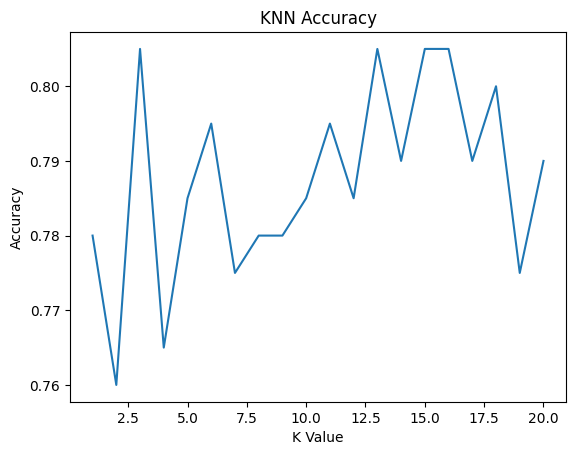

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1,21), scores)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy")
plt.show()

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

print(best_k)

3


In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
knn_pred = knn_model.predict(X_test)

print(accuracy_score(y_test, knn_pred))

0.805


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.73      0.74        77
           1       0.83      0.85      0.84       123

    accuracy                           0.81       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.81      0.80       200

